#### Glass Classification

- This is a Glass Identification Data Set from UCI. It contains 10 attributes including id. The response is glass type(discrete 7 values)

- Data exploration of this dataset reveals two important characteristics :
1) The variables are highly corelated with each other including the response variables:
So which kind of ML algorithm is most suitable for this dataset Random Forest , KNN or other? Also since dataset is too small is there any chance of applying PCA or it should be completely avoided?

2) Highly Skewed Data:
Is scaling sufficient or are there any other techniques which should be applied to normalize data? Like BOX-COX Power transformation?

In [1]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading up the data
df = pd.read_csv('glass.csv')
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [3]:
#finding information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RI,214.0,1.518365,0.003037,1.51115,1.516522,1.51768,1.519157,1.53393
Na,214.0,13.407850,0.816604,10.73000,12.907500,13.30000,13.825000,17.38000
Mg,214.0,2.684533,1.442408,0.00000,2.115000,3.48000,3.600000,4.49000
Al,214.0,1.444907,0.499270,0.29000,1.190000,1.36000,1.630000,3.50000
Si,214.0,72.650935,0.774546,69.81000,72.280000,72.79000,73.087500,75.41000
K,214.0,0.497056,0.652192,0.00000,0.122500,0.55500,0.610000,6.21000
Ca,214.0,8.956963,1.423153,5.43000,8.240000,8.60000,9.172500,16.19000
Ba,214.0,0.175047,0.497219,0.00000,0.000000,0.00000,0.000000,3.15000
Fe,214.0,0.057009,0.097439,0.00000,0.000000,0.00000,0.100000,0.51000
Type,214.0,2.780374,2.103739,1.00000,1.000000,2.00000,3.000000,7.00000


In [5]:
df.isnull().sum
#conclusion: none of the variables in every column are null

<bound method DataFrame.sum of         RI     Na     Mg     Al     Si      K     Ca     Ba     Fe   Type
0    False  False  False  False  False  False  False  False  False  False
1    False  False  False  False  False  False  False  False  False  False
2    False  False  False  False  False  False  False  False  False  False
3    False  False  False  False  False  False  False  False  False  False
4    False  False  False  False  False  False  False  False  False  False
..     ...    ...    ...    ...    ...    ...    ...    ...    ...    ...
209  False  False  False  False  False  False  False  False  False  False
210  False  False  False  False  False  False  False  False  False  False
211  False  False  False  False  False  False  False  False  False  False
212  False  False  False  False  False  False  False  False  False  False
213  False  False  False  False  False  False  False  False  False  False

[214 rows x 10 columns]>

#### Pairplot
- doing a pair plot to see if there is a distribtution between each single vairables

<Figure size 1000x600 with 0 Axes>

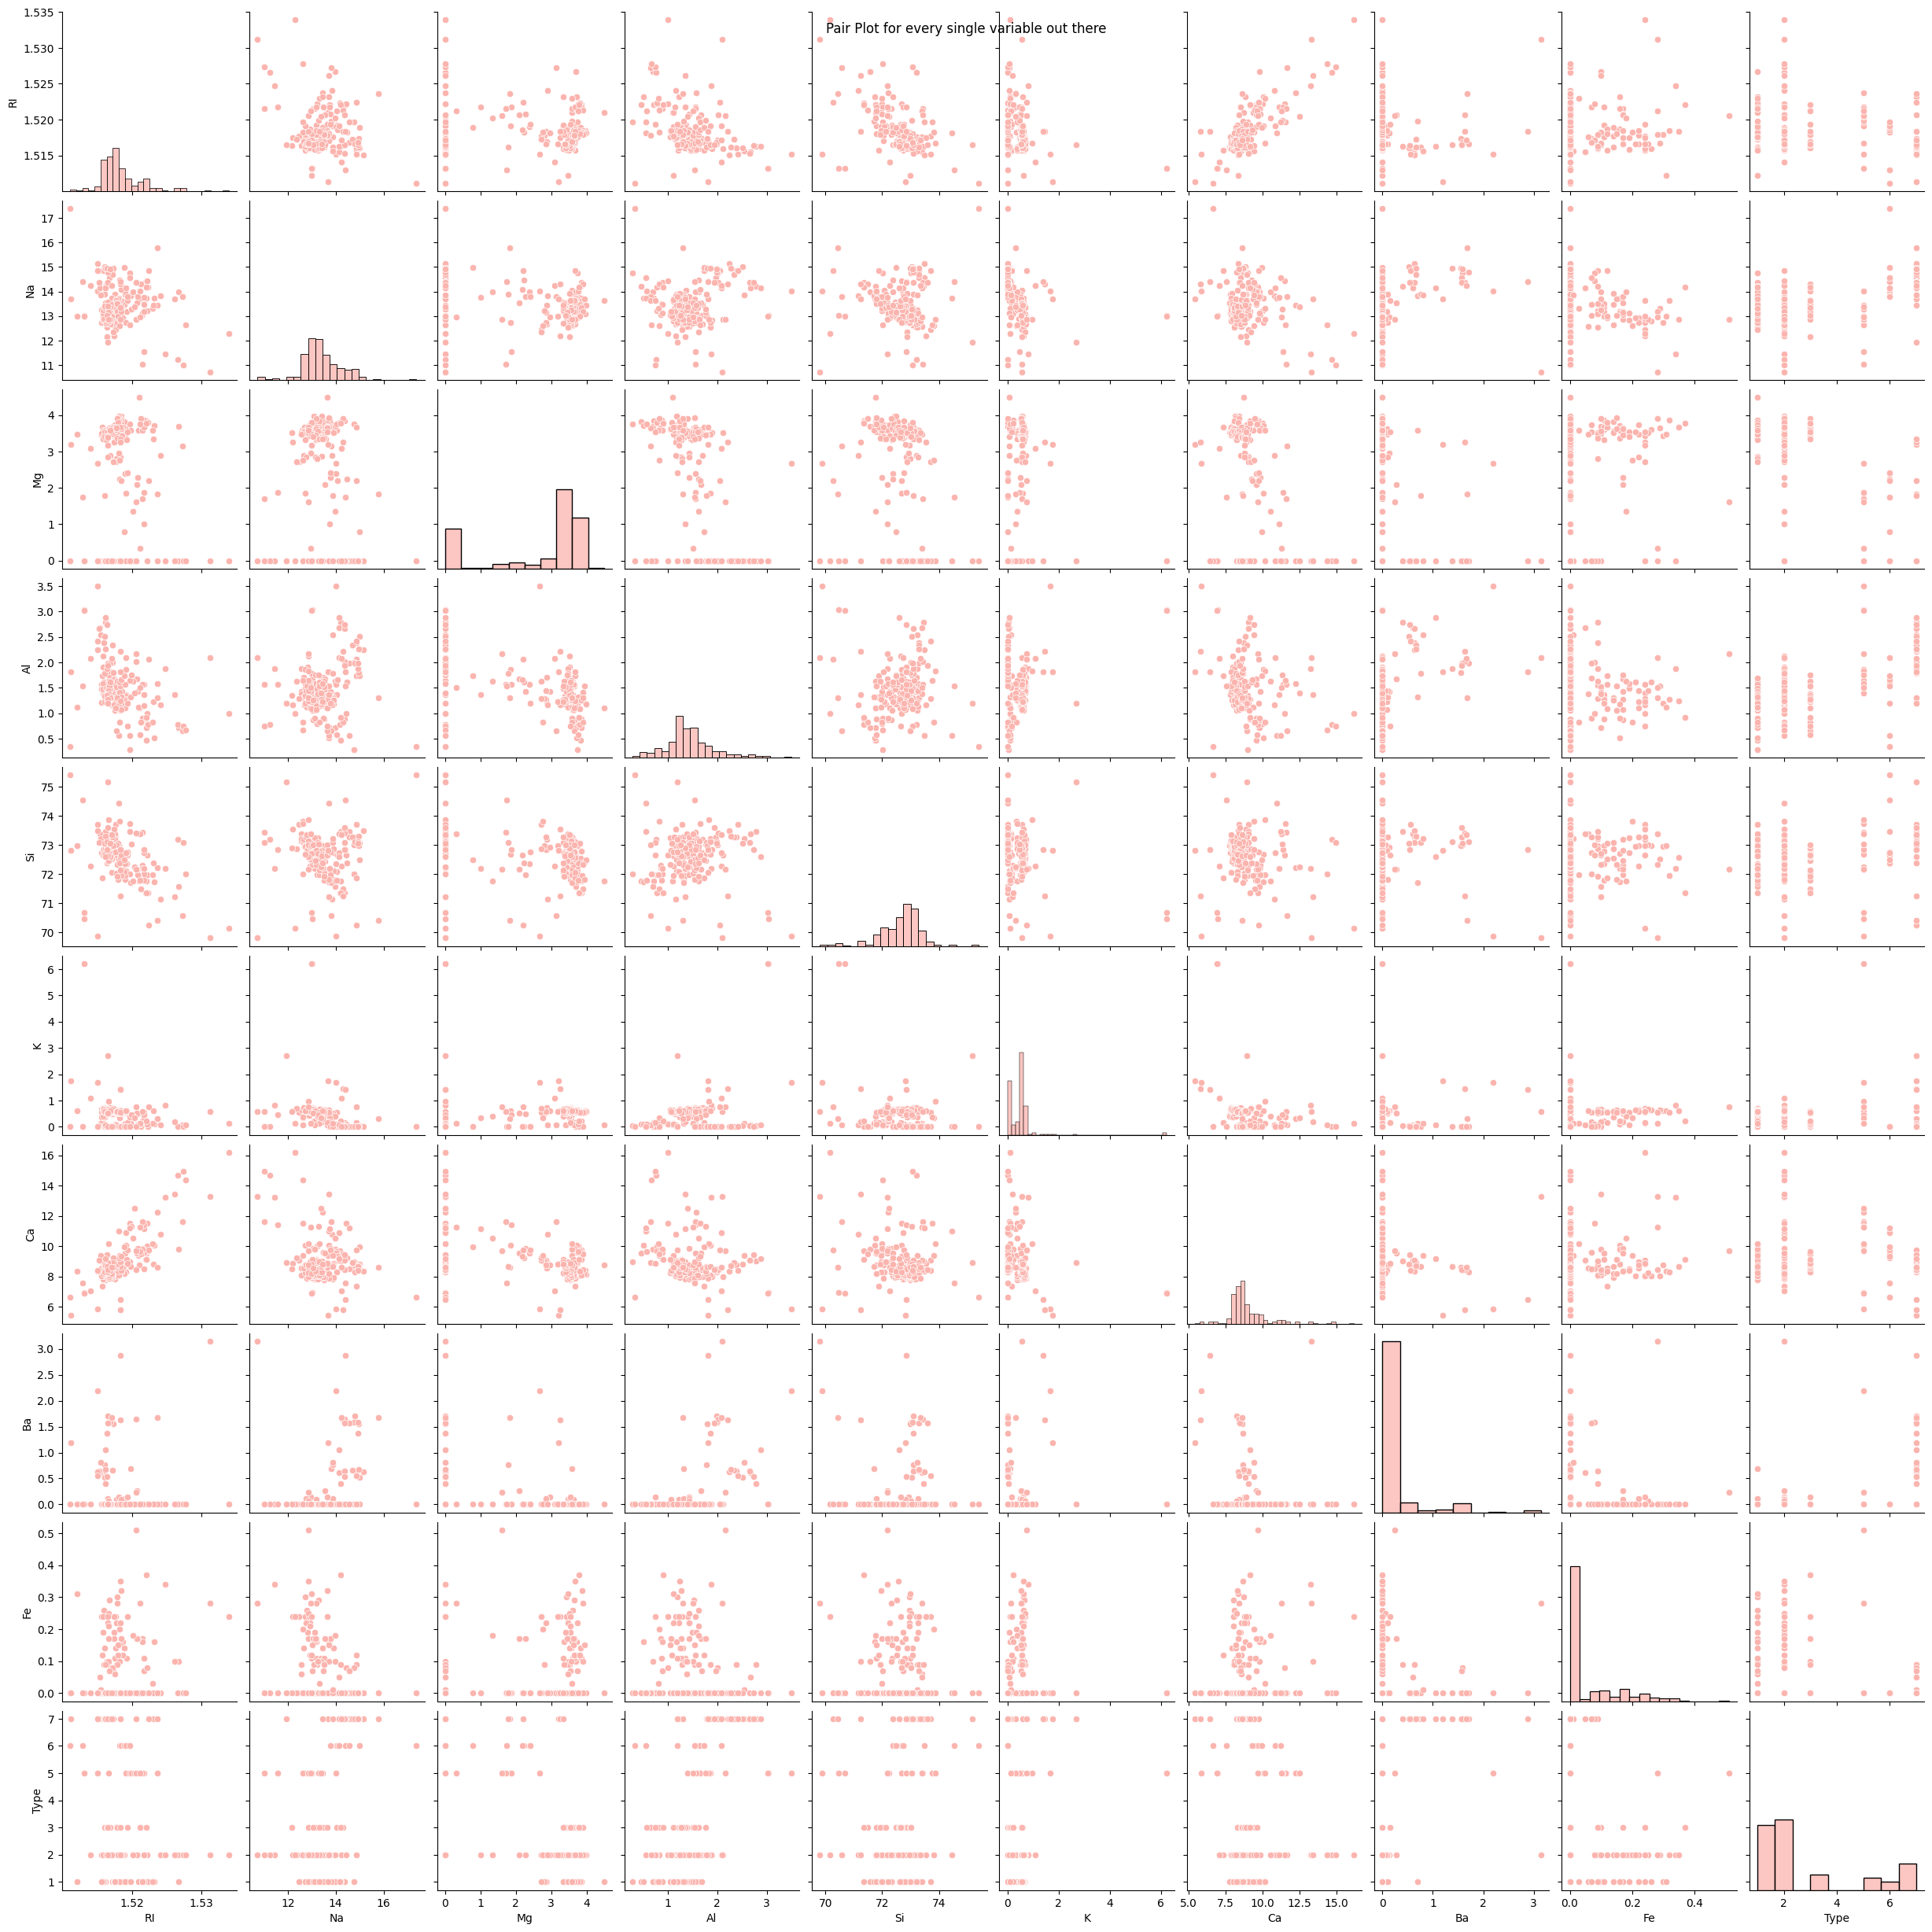

In [6]:
sns.set_palette("Pastel1")
plt.figure(figsize = (10,6))
sns.pairplot(df)
plt.suptitle("Pair Plot for every single variable out there")
plt.show()

#### Correlation
- We move on to checking for any correlations between any variables

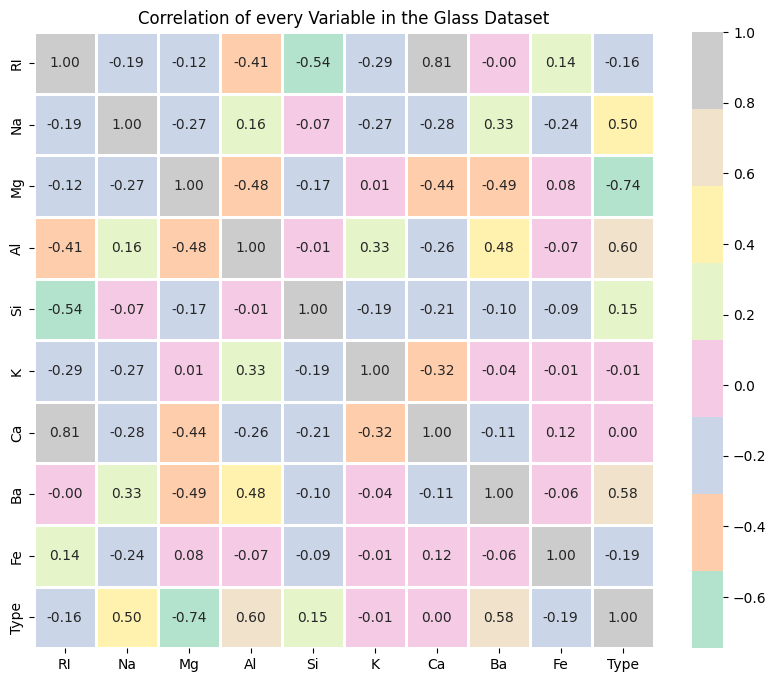

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,fmt='.2f',cmap = 'Pastel2',linewidth=2)
plt.title('Correlation of every Variable in the Glass Dataset')
plt.show()

In [8]:
#Looking at the pairplot, i think my vairable that I want to classifiy Types and maybe the other ones 

y = df['Type'] #target 
X = df.drop('Type',axis=1) #others


#print(y.iloc[:,0]) #printing the first column

In [9]:
class_counts = y.value_counts()
print(class_counts)


Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64


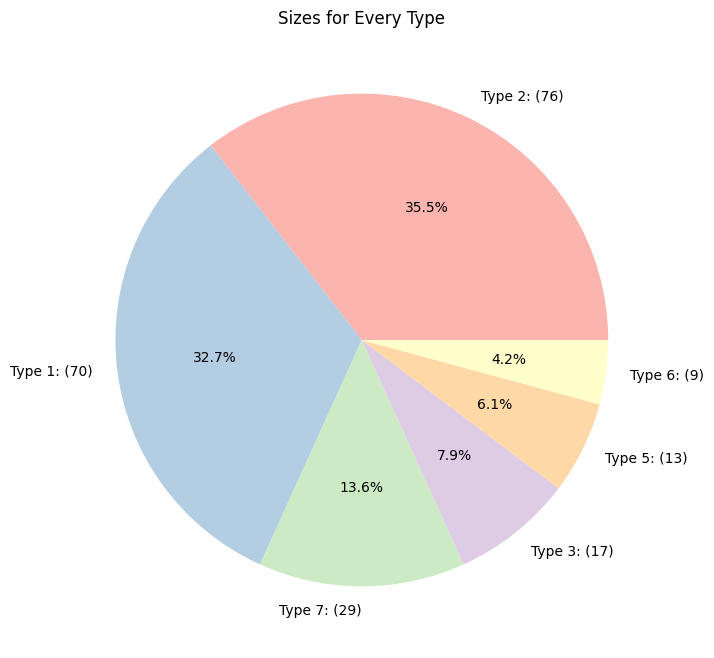

In [10]:
#constructing a pie chart for every type out there

labels = [f"Type {cls}: ({count})" 
          for cls, count in zip(class_counts.index, class_counts)]
plt.figure(figsize=(10,8))
plt.pie(
    class_counts,
    labels=labels,
    autopct='%1.1f%%'
)
plt.title("Sizes for Every Type")
plt.show()

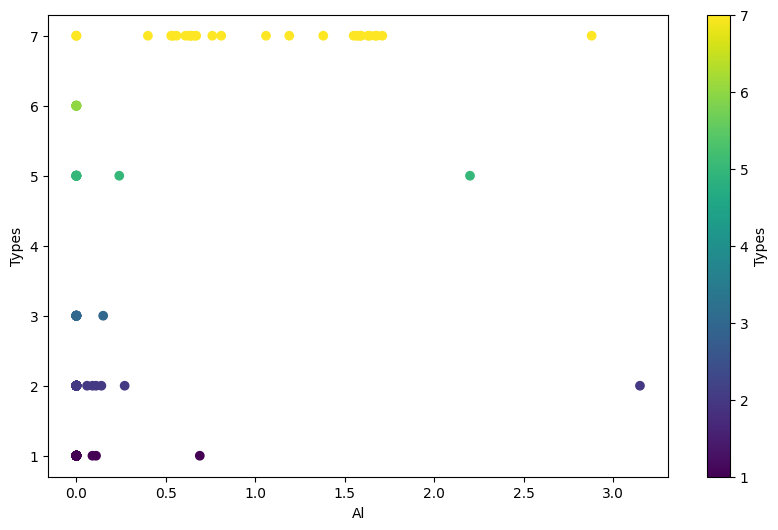

In [11]:
#printing the scatter graphs
plt.figure(figsize=(10,6))
plt.scatter(X.iloc[:, [7]], y, c=y, cmap='viridis')
plt.xlabel('Al')
plt.ylabel('Types')
plt.colorbar(label='Types')
plt.show()

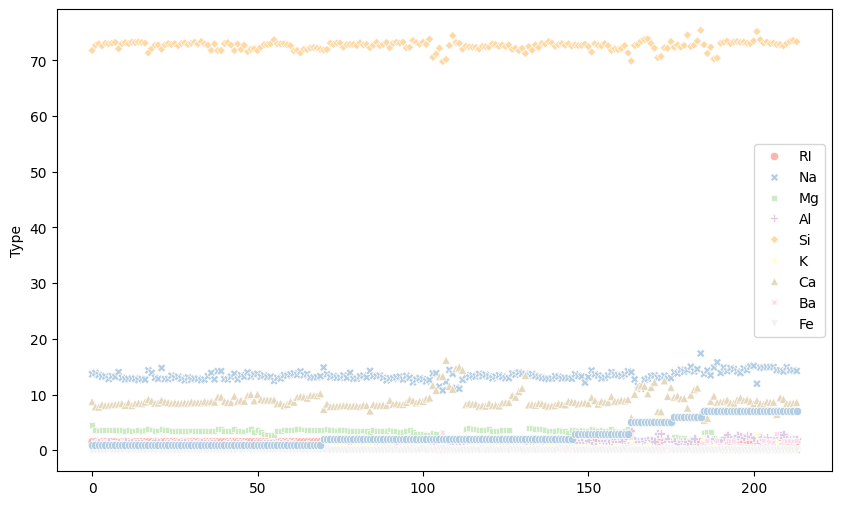

In [12]:
plt.figure(figsize = (10,6))
sns.scatterplot(X)
sns.scatterplot(y)
plt.show()

In [13]:
#### Training and testing the data
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

- will be testing out some classification algorithms 
- starting off with k-nearest neighbours

In [14]:
print(X_train.shape)  # (n_samples, n_features)
print(y_train.shape) 

(171, 9)
(171,)


In [15]:
#Importing the libraries
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

knnClassifier = KNeighborsClassifier(
    n_neighbors=5,
    metric="manhattan",
    p=2
)

knn_model = Pipeline(steps=[
    ('preprocessor', StandardScaler()),
    ('classifier', knnClassifier)
])

knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)

#### Evaluating the model

##### -Accuracy Score-

In [16]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test,y_pred)
print(f"Accuracy : {acc}")

Accuracy : 0.7906976744186046


##### -Confusion Matrix-

In [17]:
from sklearn.metrics import confusion_matrix

cf = confusion_matrix(y_test,y_pred)
print(cf)

[[11  0  0  0  0  0]
 [ 4 10  0  0  0  0]
 [ 3  0  0  0  0  0]
 [ 0  2  0  2  0  0]
 [ 0  0  0  0  3  0]
 [ 0  0  0  0  0  8]]


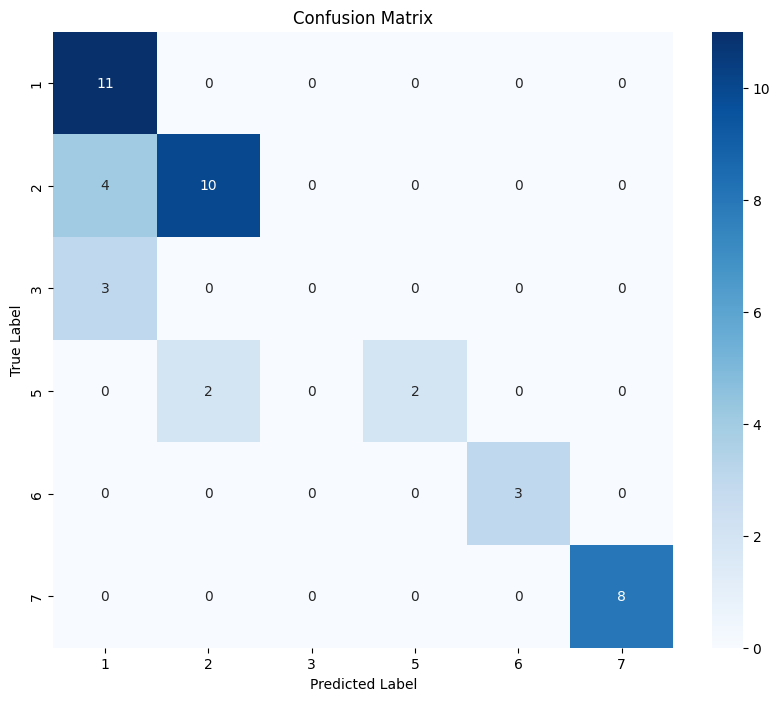

In [27]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

##### -Classification Report-

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.61      1.00      0.76        11
           2       0.83      0.71      0.77        14
           3       0.00      0.00      0.00         3
           5       1.00      0.50      0.67         4
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         8

    accuracy                           0.79        43
   macro avg       0.74      0.70      0.70        43
weighted avg       0.78      0.79      0.76        43



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

##### -Cross-Validation Accuracy-

In [19]:
from sklearn.model_selection import cross_val_score
    
scores = cross_val_score(knn_model, X, y, cv=5)
print(f"Cross Validation Score = {scores.mean():.3f}")

Cross Validation Score = 0.659


In [23]:
# I want to plot a graph to using the accuracy points and cross validation accuracy 
acc_score_table = []
mean_cross_val_score_table = []
#Trialing for multiple values of k to see if there is a difference
knnClassifier = KNeighborsClassifier(
    n_neighbors=5,
    metric="manhattan",
)

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn_model = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', knn)
    ])

    knn_model.fit(X_train, y_train)
    y_pred = knn_model.predict(X_test)
    acc_score_table.append(accuracy_score(y_test,y_pred))
    mean_cross_val_score_table.append(cross_val_score(knn_model, X, y, cv=5).mean())
    

    print(f"Accuracy Score for k = {k} : {accuracy_score(y_test,y_pred)}")
    print(f"Mean Cross Validation Score for k={k} = {cross_val_score(knn_model, X, y, cv=5).mean():3f}")
    print("")

Accuracy Score for k = 1 : 0.7674418604651163
Mean Cross Validation Score for k=1 = 0.621152

Accuracy Score for k = 2 : 0.6976744186046512
Mean Cross Validation Score for k=2 = 0.663677

Accuracy Score for k = 3 : 0.813953488372093
Mean Cross Validation Score for k=3 = 0.677630

Accuracy Score for k = 4 : 0.7209302325581395
Mean Cross Validation Score for k=4 = 0.654264

Accuracy Score for k = 5 : 0.6976744186046512
Mean Cross Validation Score for k=5 = 0.668217

Accuracy Score for k = 6 : 0.6511627906976745
Mean Cross Validation Score for k=6 = 0.621484

Accuracy Score for k = 7 : 0.7209302325581395
Mean Cross Validation Score for k=7 = 0.593355

Accuracy Score for k = 8 : 0.6976744186046512
Mean Cross Validation Score for k=8 = 0.598117

Accuracy Score for k = 9 : 0.6744186046511628
Mean Cross Validation Score for k=9 = 0.598117

Accuracy Score for k = 10 : 0.627906976744186
Mean Cross Validation Score for k=10 = 0.584053

Accuracy Score for k = 11 : 0.627906976744186
Mean Cross Val

<Figure size 1000x1200 with 0 Axes>

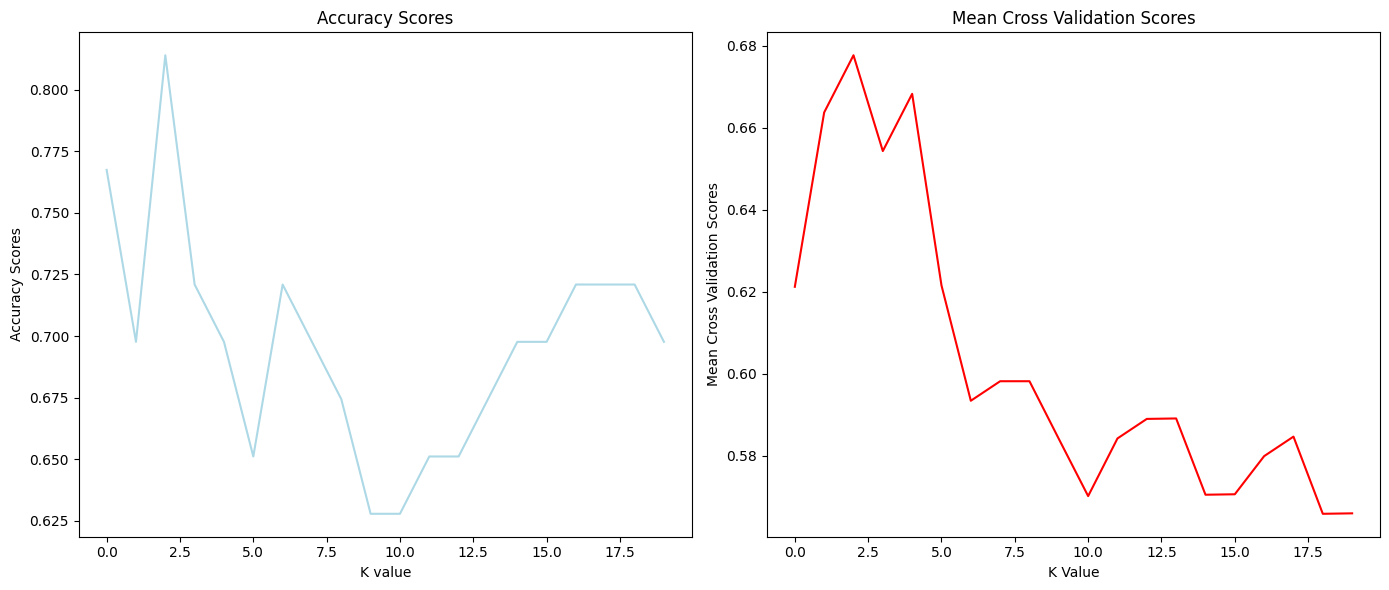

In [21]:
plt.figure(figsize = (10,12))

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].plot(acc_score_table,c = "lightblue")
ax[0].set_title("Accuracy Scores")
ax[0].set_xlabel("K value")
ax[0].set_ylabel("Accuracy Scores")

ax[1].plot(mean_cross_val_score_table, c="red")
ax[1].set_title("Mean Cross Validation Scores")
ax[1].set_xlabel("K Value")
ax[1].set_ylabel("Mean Cross Validation Scores")

plt.tight_layout()
plt.show()
